In [3]:
! pip install opendatasets

In [4]:

import opendatasets as od
od.download("https://www.kaggle.com/datasets/drscarlat/melanoma/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yasir90
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/drscarlat/melanoma


100%|██████████| 5.26G/5.26G [03:05<00:00, 30.4MB/s]


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [6]:
train_dir = "/content/melanoma/DermMel/train_sep"
valid_dir = "/content/melanoma/DermMel/valid"
test_dir = "/content/melanoma/DermMel/test"

In [7]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 10682 images belonging to 2 classes.
Found 3562 images belonging to 2 classes.
Found 3561 images belonging to 2 classes.


In [9]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [14]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 266s 746ms/step - accuracy: 0.7416 - loss: 0.5110 - val_accuracy: 0.8425 - val_loss: 0.3597 - learning_rate: 1.0000e-04
Epoch 2/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 196s 588ms/step - accuracy: 0.8162 - loss: 0.3893 - val_accuracy: 0.8585 - val_loss: 0.3220 - learning_rate: 1.0000e-04
Epoch 3/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 199s 594ms/step - accuracy: 0.8418 - loss: 0.3504 - val_accuracy: 0.8689 - val_loss: 0.3067 - learning_rate: 1.0000e-04
Epoch 4/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 201s 601ms/step - accuracy: 0.8463 - loss: 0.3491 - val_accuracy: 0.8602 - val_loss: 0.3188 - learning_rate: 1.0000e-04
Epoch 5/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 223s 667ms/step - accuracy: 0.8580 - loss: 0.3267 - val_accuracy: 0.8773 - val_loss: 0.2915 - learning_rate: 1.0000e-04
Epoch 6/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 205s 614ms/step - accuracy: 0.8548 - loss: 0.3270 - val_accuracy: 0.8411 - val_loss: 0.3538 - learning_rate: 1.0000e-04
Epoch 7/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 

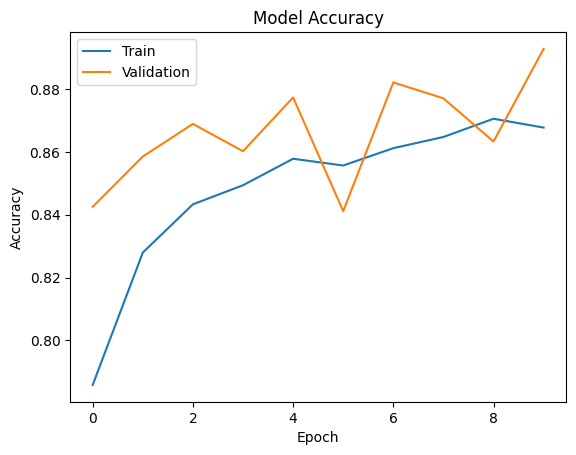

In [15]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [16]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

112/112 ━━━━━━━━━━━━━━━━━━━━ 36s 324ms/step - accuracy: 0.8984 - loss: 0.2688
Test Accuracy: 0.8831788897514343


112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 239ms/step


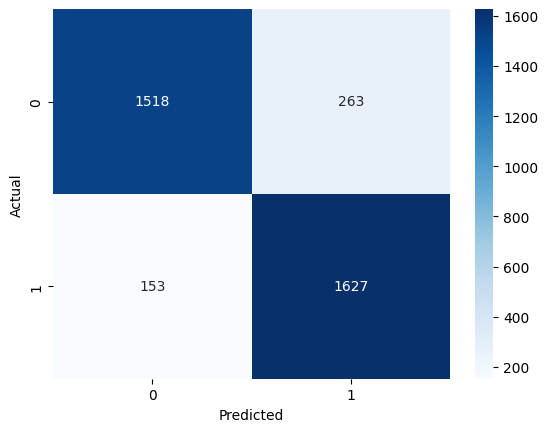

In [17]:
predictions = model.predict(test_data)
y_pred = np.round(predictions)

cm = confusion_matrix(test_data.classes, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
print(classification_report(test_data.classes, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1781
           1       0.86      0.91      0.89      1780

    accuracy                           0.88      3561
   macro avg       0.88      0.88      0.88      3561
weighted avg       0.88      0.88      0.88      3561



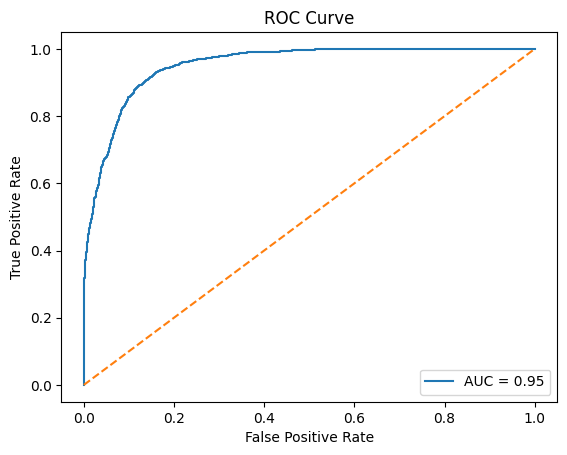

In [19]:
fpr, tpr, thresholds = roc_curve(test_data.classes, predictions)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
import cv2

img_path = "/content/melanoma/DermMel/test/Melanoma/AUG_0_1047.jpeg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)

print("Prediction:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Prediction: [[0.09444387]]


In [22]:
model.save("melanoma_vgg16_model.h5")

In [23]:
import json

class_indices = train_data.class_indices

with open("class.json", "w") as f:
    json.dump(class_indices, f)

print(class_indices)

{'Melanoma': 0, 'NotMelanoma': 1}


In [35]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names
class_names = ['melanoma', 'notmelanoma']

# image path
img_path = "/content/melanoma/DermMel/test/Melanoma/AUG_0_1273.jpeg"

# load image
img = image.load_img(img_path, target_size=(224,224))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
if prediction[0][0] > 0.5:
    predicted_class = class_names[1]
else:
    predicted_class = class_names[0]

# confidence
confidence = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction: melanoma
Confidence: 0.90744716


In [46]:
import numpy as np
from tensorflow.keras.preprocessing import image

# class names
class_names = ['melanoma', 'notmelanoma']

# image path
img_path = "/content/melanoma/DermMel/test/Melanoma/AUG_0_1152.jpeg"

# load image
img = image.load_img(img_path, target_size=(224,224))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# expand dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

# predicted class
if prediction[0][0] > 0.5:
    predicted_class = class_names[1]
else:
    predicted_class = class_names[0]

# confidence
confidence = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Prediction: melanoma
Confidence: 0.8291936


In [47]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [48]:
last_conv_layer_name = "block5_conv3"

In [49]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [50]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [51]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [52]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

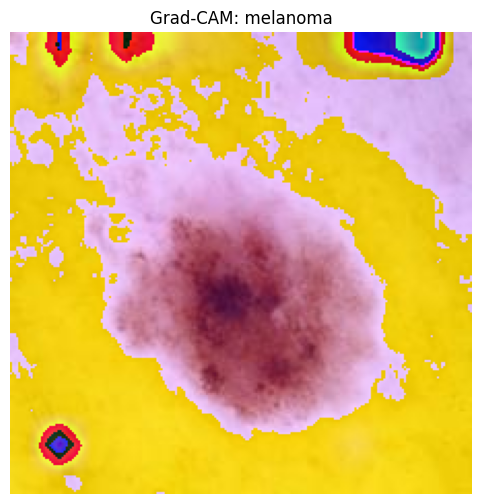

In [53]:
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM: " + predicted_class)
plt.axis("off")
plt.show()

In [54]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e638cde5336119829e7feb2850a2268daaceaf620c6cfa93f68d84e4c7b15ef0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [56]:
IMG_SIZE = 224

img_path = "/content/melanoma/DermMel/test/Melanoma/AUG_0_1127.jpeg"

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)

img_array = img_array / 255.0

In [57]:
def predict_fn(images):
    images = np.array(images)
    return model.predict(images)

In [58]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_array.astype('double'),
    predict_fn,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

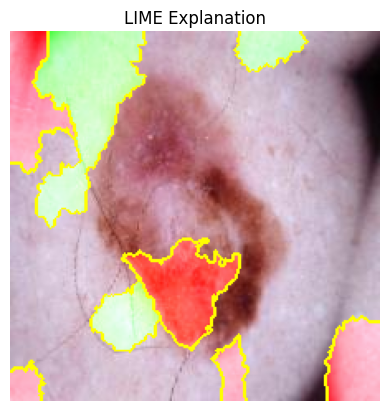

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=10,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()